In [1]:
data = []

with open("train.csv") as csv:
    while line := csv.readline():
        data.append(list(map(lambda x: x.strip(), line.split(";"))))

In [2]:
import numpy as np

In [3]:
xs, ys = [], []
graph_x, graph_y, colors = [], [], []

for x1, x2, name in data:
    xs.append([float(x1), float(x2)])
    ys.append(1.0 if name == "caterpillar" else -1.0)

    graph_x.append(int(x1))
    graph_y.append(int(x2))
    
    colors.append("red" if name == "caterpillar" else "blue")

x_train = np.array(xs, dtype="float")
y_train = np.array(ys, dtype="float")

In [4]:
from sklearn import svm

In [5]:
clf = svm.SVC(kernel="linear")
clf.fit(x_train, y_train)

support_vectors = clf.support_vectors_

support_x = []
support_y = []

for v in support_vectors:
    support_x.append(int(v[0]))
    support_y.append(int(v[1]))

support_vectors, clf.dual_coef_, clf.intercept_

(array([[20., 30.],
        [30., 45.],
        [20., 45.]]),
 array([[-0.00888889, -0.02      ,  0.02888889]]),
 array([-1.]))

In [6]:
lin_clf = svm.LinearSVC()
lin_clf.fit(x_train, y_train)

w = lin_clf.coef_[0]
print(w)

[-0.24462185  0.13071638]


In [7]:
import matplotlib.pyplot as plt

x = np.linspace(0, 50, 2)

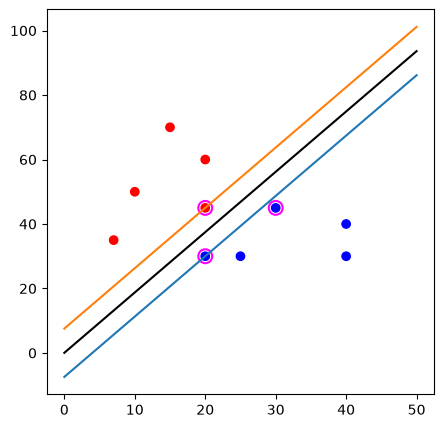

In [8]:
plt.figure(figsize=(5, 5))
plt.scatter(graph_x, graph_y, c=colors)
plt.scatter(support_x, support_y, facecolors="none", edgecolors="magenta", s=100, linewidths=1.5)

# w0 * x + w1 * y + b = 0 -> y = -(w0 * x + b) / w1
k = -w[0] / w[1]
y = k * x - lin_clf.intercept_ / w[1]
plt.plot(x, y, "k")

plt.plot(x, k * (x - support_x[0]) + support_y[0])
plt.plot(x, k * (x - support_x[2]) + support_y[2])

In [9]:
samples = np.array([[20, 20], [30, 30], [40, 40], [10, 40]])

In [10]:
lin_clf.predict(samples)

array([-1., -1., -1.,  1.])

In [11]:
predictions = np.array([0.0] * len(samples))

for i, sample in enumerate(samples):
    predictions[i] = 1.0 if np.dot(w, sample) + lin_clf.intercept_[0] > 0 else -1.0

predictions

array([-1., -1., -1.,  1.])